In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

(X1_train, y1_train), (X1_test, y1_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalizing
X1_train=X1_train.astype('float32')/255.0
X1_test=X1_test.astype('float32')/255.0
X1_train[9].shape

(28, 28)

In [ ]:
#images to 1 D
X1_train=X1_train.reshape(-1,28*28)
X1_test=X1_test.reshape(-1,28*28)
X1_train[1].shape

(784,)

In [ ]:
# diferent values for hyperparameter tunninng
config= [
    [1, 64, 0.001, 32],
    [2, 64, 0.001, 32],
    [2, 128, 0.001, 32],
    [2, 128, 0.01, 32],
    [2, 128, 0.001, 64]
]

res = []


In [ ]:
for layers, neu, lr, batch in config:

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))

    for _ in range(layers):
        model.add(keras.layers.Dense(neu, activation='relu'))

    model.add(keras.layers.Dense(10, activation='softmax'))

    opt = keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X1_train, y1_train,
                        epochs=5,
                        batch_size=batch,
                        verbose=0)

    loss, acc = model.evaluate(X1_test, y1_test, verbose=0)

    res.append([layers, neu, lr, batch, acc, loss])

In [ ]:
import pandas as pd

df = pd.DataFrame(res, columns=[
    "Layers", "Neurons", "Learning Rate", "Batch Size", "Accuracy", "Loss"
])

print(df)

   Layers  Neurons  Learning Rate  Batch Size  Accuracy      Loss
0       1       64          0.001          32    0.9736  0.085875
1       2       64          0.001          32    0.9736  0.089200
2       2      128          0.001          32    0.9749  0.084702
3       2      128          0.010          32    0.9595  0.161031
4       2      128          0.001          64    0.9787  0.067947


Text(0, 0.5, 'Accuracy')

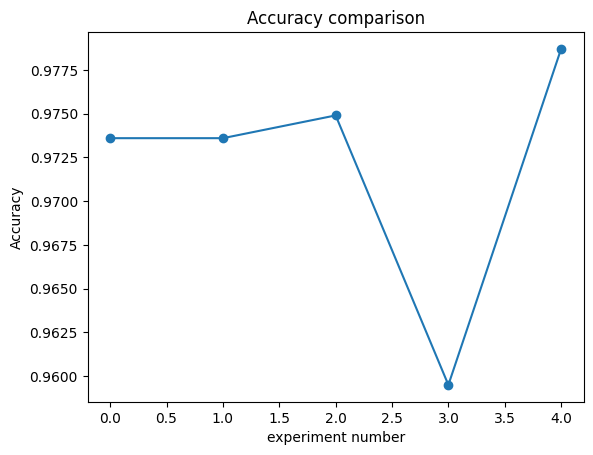

In [ ]:

plt.plot(df['Accuracy'], marker='o')
plt.title("Accuracy comparison")
plt.xlabel("experiment number")
plt.ylabel("Accuracy")


Text(0, 0.5, 'loss')

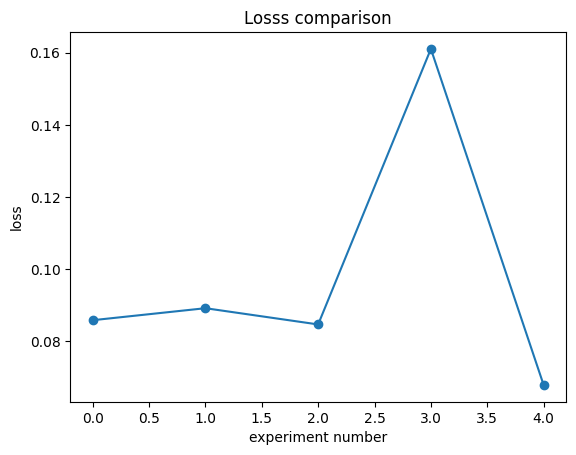

In [ ]:
plt.plot(df['Loss'], marker='o')
plt.title("Losss comparison")
plt.xlabel("experiment number")
plt.ylabel("loss")